# Analise local de longevidade

Este notebook le todas as planilhas cadastradas em `data/metadata.csv`, calcula os indicadores de longevidade e gera os graficos em `outputs/figures`.

In [8]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config.settings import K_MAX
from src.data.loaders import load_life_tables_from_metadata, load_metadata
from src.analysis.hazard import add_survival_hazard
from src.analysis.indicators import build_indicators, build_milestone_long, milestone_differences
from src.visualization.plots import (
    plot_fixed_age_hazards,
    plot_hazard_curves,
    plot_milestone_bars,
    plot_milestone_differences,
    plot_survival_curves,
)

## Planilhas cadastradas

In [9]:
metadata = load_metadata()
metadata

,filename,country,year,sex,label
0,tabua_vida_feminina_nordeste_2025.xlsx,Nordeste (Brasil),2025,Feminino,Nordeste (Brasil) - Feminino
1,tabua_vida_feminina_chile_2023.xlsx,Chile,2023,Feminino,Chile - Feminino
2,tábua de vida masculina - nordeste 2025.xlsx,Nordeste (Brasil),2025,Masculino,Nordeste (Brasil) - Masculino
3,tábua de vida masculina - chile 2023.xlsx,Chile,2023,Masculino,Chile - Masculino


## Carregamento e indicadores

In [10]:
raw = load_life_tables_from_metadata()
life_tables = add_survival_hazard(raw)
indicators = build_indicators(life_tables, k_max=K_MAX)
milestones = build_milestone_long(life_tables, k_max=K_MAX)

indicators

,country,year,age_min,age_max,H_max,H_60,H_70,H_80,H_90,H_100,l_100,x_H1,x_H2,x_H3,x_H4,x_H5,x_H6,x_H7,x_H8
0,Chile,2023,0.0,90.0,1.367944,0.064922,0.148925,0.375851,1.071908,NaN,NaN,88.092050,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Nordeste (Brasil),2025,0.0,90.0,1.845215,0.104435,0.208108,0.467868,1.330084,NaN,NaN,82.827433,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Graficos principais

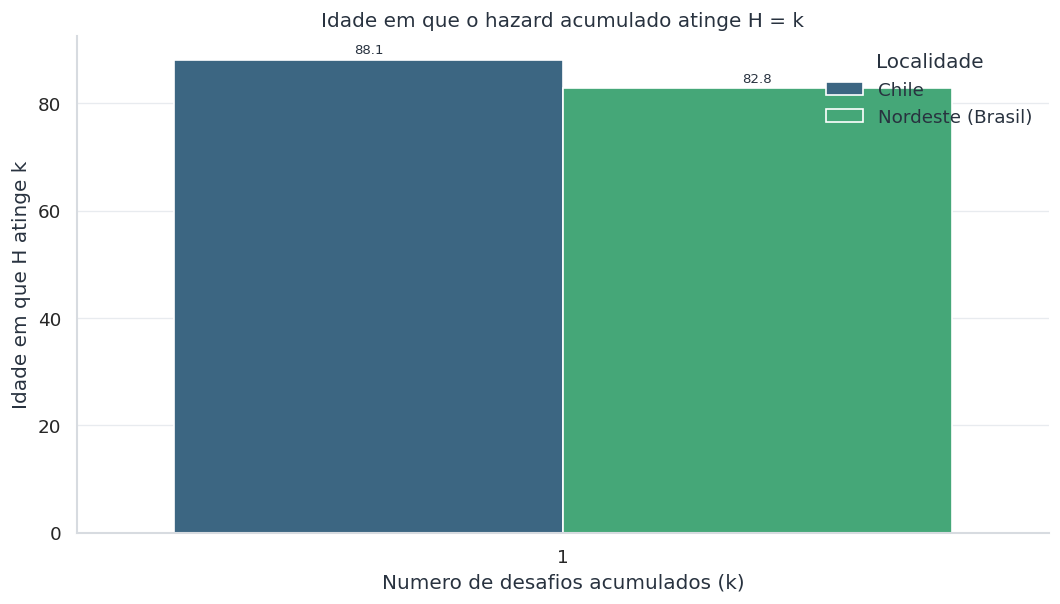

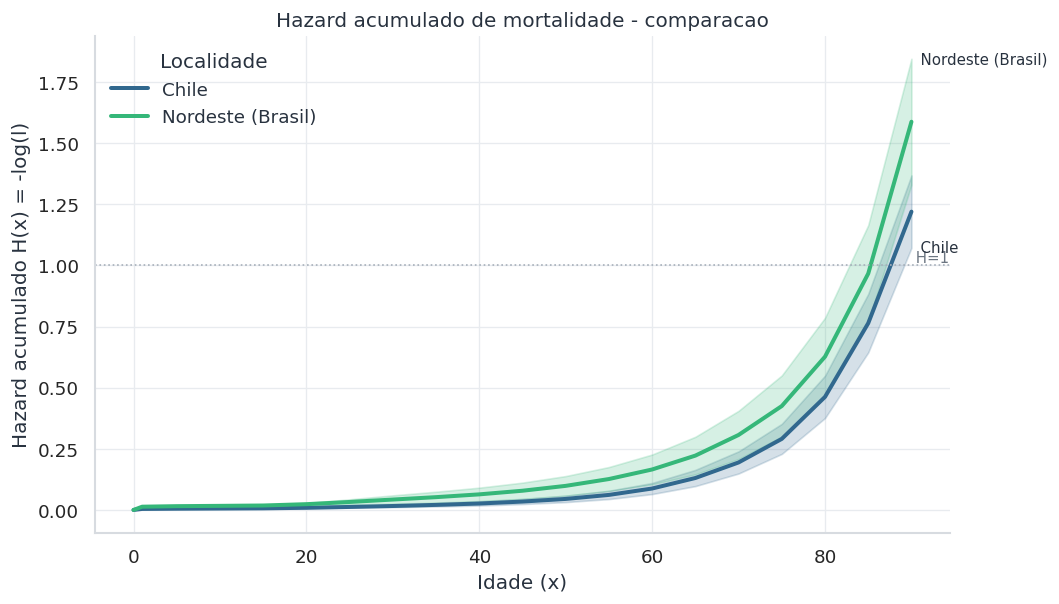

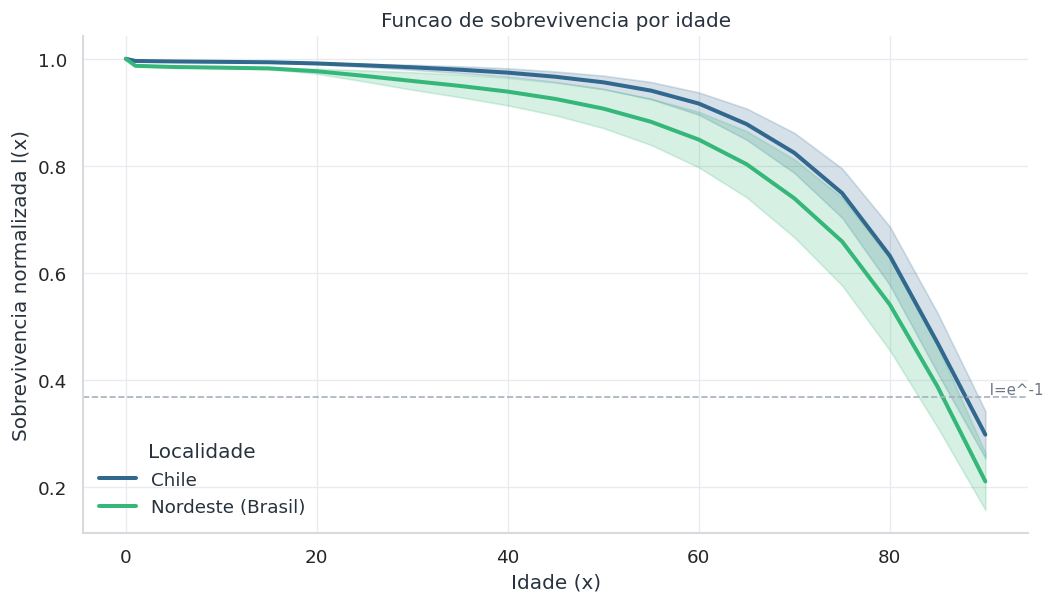

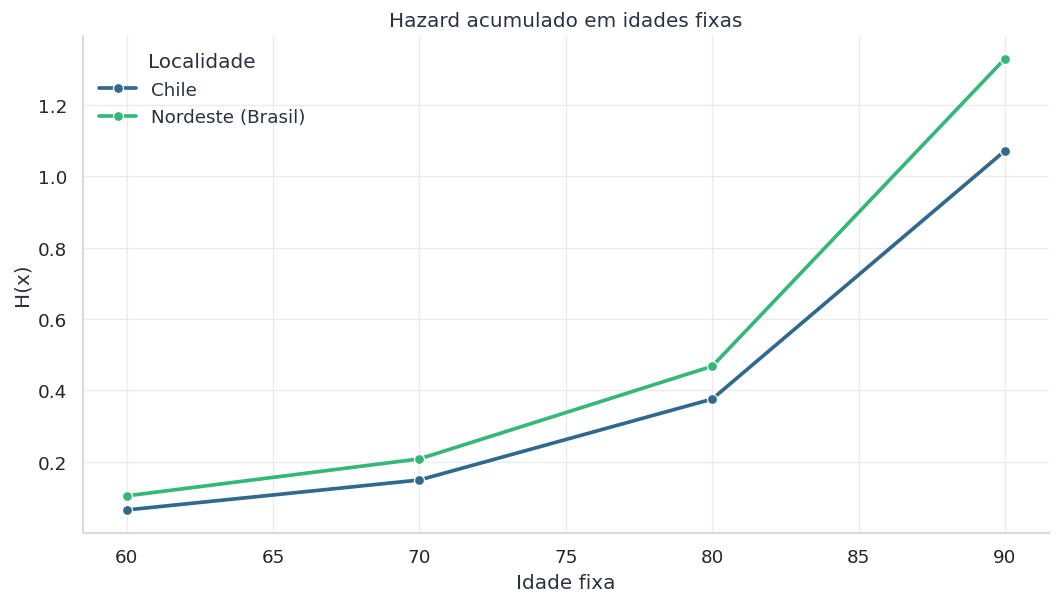

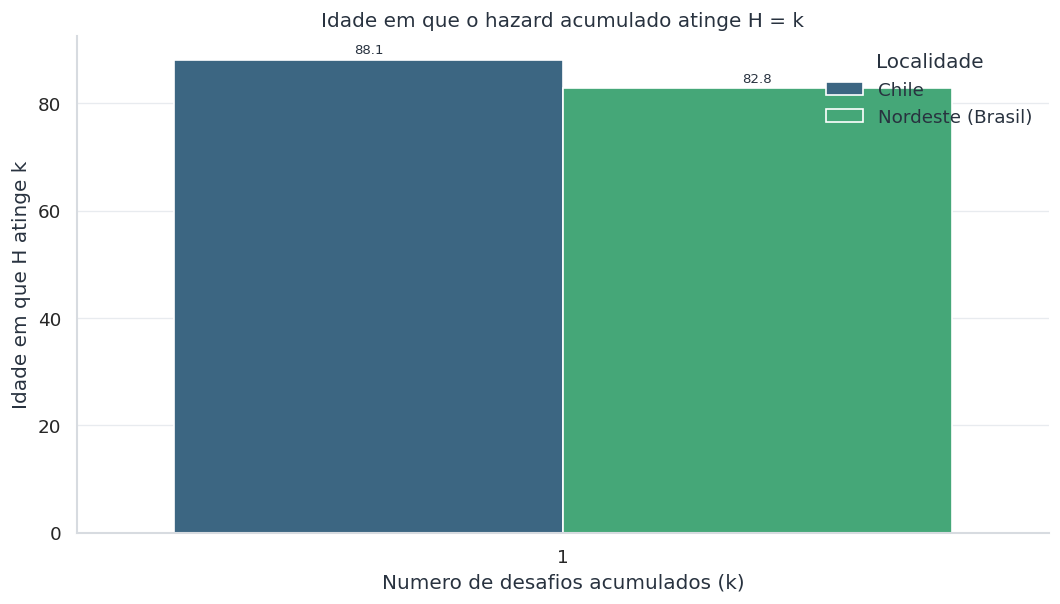

In [11]:
plot_hazard_curves(life_tables)
plot_survival_curves(life_tables)
plot_fixed_age_hazards(indicators)
plot_milestone_bars(milestones)

## Diferencas em relacao a uma referencia

In [12]:
reference_country = "Chile - Feminino"
differences = milestone_differences(milestones, reference_country=reference_country)
differences

,country,year,milestone,age_at_k,k,outlived_pct,reference_age_at_k,difference_years,reference_country


In [13]:
if not differences.empty:
    plot_milestone_differences(differences)